In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import seaborn as sns

Honest up front note: The best way to learn python/pandas etc. is to work on a problem and google your way through as you encounter things you want to do but don't know how. Hopefully these notebooks will help as a resource / reference for things that arise a lot.

I will use jupyter notebooks for our work and class demos. I use the Python package manager Anaconda installed on my local machine to run notebooks and install necessary packages. Another option is Google CoLab if you prefer.

### Quick review of data manipulation and plotting. 

In [3]:
mar=pd.read_csv('marathon_results_2015.csv')

In [4]:
mar19=pd.read_csv('Boston2019.csv')

In [5]:
mar19.head()

,Rank_Tot,Age,Gender,Country,Result_hr,Result_sec,Rank_Gender,Country_code
0,1,30,M,Kenya,2:07:57,7677,1,KEN
1,2,29,M,Ethiopia,2:07:59,7679,2,ETH
2,3,34,M,Kenya,2:08:07,7687,3,KEN
3,4,32,M,Kenya,2:08:54,7734,4,KEN
4,5,26,M,Kenya,2:08:55,7735,5,KEN


We can check out the data lots of ways:

In [6]:
mar.head()

,Unnamed: 0,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,...,25K,30K,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division
0,0,3,"Desisa, Lelisa",25,M,Ambo,NaN,ETH,NaN,NaN,...,1:16:07,1:32:00,1:47:59,2:02:39,0:04:56,-,2:09:17,1,1,1
1,1,4,"Tsegay, Yemane Adhane",30,M,Addis Ababa,NaN,ETH,NaN,NaN,...,1:16:07,1:31:59,1:47:59,2:02:42,0:04:58,-,2:09:48,2,2,2
2,2,8,"Chebet, Wilson",29,M,Marakwet,NaN,KEN,NaN,NaN,...,1:16:07,1:32:00,1:47:59,2:03:01,0:04:59,-,2:10:22,3,3,3
3,3,11,"Kipyego, Bernard",28,M,Eldoret,NaN,KEN,NaN,NaN,...,1:16:07,1:32:00,1:48:03,2:03:47,0:05:00,-,2:10:47,4,4,4
4,4,10,"Korir, Wesley",32,M,Kitale,NaN,KEN,NaN,NaN,...,1:16:07,1:32:00,1:47:59,2:03:27,0:05:00,-,2:10:49,5,5,5


In [7]:
mar.columns

Index(['Unnamed: 0', 'Bib', 'Name', 'Age', 'M/F', 'City', 'State', 'Country',
       'Citizen', 'Unnamed: 9', '5K', '10K', '15K', '20K', 'Half', '25K',
       '30K', '35K', '40K', 'Pace', 'Proj Time', 'Official Time', 'Overall',
       'Gender', 'Division'],
      dtype='object')

In [8]:
mar.dtypes

Unnamed: 0        int64
Bib              object
Name             object
Age               int64
M/F              object
City             object
State            object
Country          object
Citizen          object
Unnamed: 9       object
5K               object
10K              object
15K              object
20K              object
Half             object
25K              object
30K              object
35K              object
40K              object
Pace             object
Proj Time        object
Official Time    object
Overall           int64
Gender            int64
Division          int64
dtype: object

In [9]:
mar.describe().round(2)

,Unnamed: 0,Age,Overall,Gender,Division
count,26598.00,26598.00,26598.00,26598.00,26598.00
mean,13298.50,42.14,13299.50,6711.79,1654.04
std,7678.33,11.29,7678.33,3944.25,1477.11
min,0.00,18.00,1.00,1.00,1.00
25%,6649.25,33.00,6650.25,3325.25,518.00
50%,13298.50,42.00,13299.50,6650.00,1205.00
75%,19947.75,50.00,19948.75,9974.75,2268.00
max,26597.00,82.00,26598.00,14581.00,6004.00


We can look at one column:

In [198]:
mar['Age'][0:10]

0    25
1    30
2    29
3    28
4    32
5    30
6    32
7    39
8    27
9    33
Name: Age, dtype: int64

Or one entry in a row, column:

In [199]:
mar.loc[2,'Age']

29

Or a picture of the data in a column:

<AxesSubplot:>

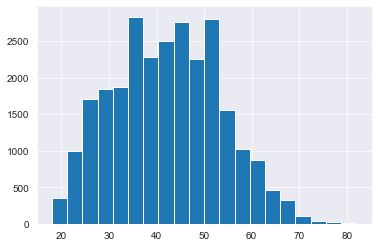

In [200]:
mar['Age'].hist(bins=20)

Or look at several columns using a list:

In [201]:
mar[['Name','Age','M/F']].head()

,Name,Age,M/F
0,"Desisa, Lelisa",25,M
1,"Tsegay, Yemane Adhane",30,M
2,"Chebet, Wilson",29,M
3,"Kipyego, Bernard",28,M
4,"Korir, Wesley",32,M


Or variations on the theme:

In [202]:
mar.loc[4,['Name','Age','M/F','Country']]

Name       Korir, Wesley
Age                   32
M/F                    M
Country              KEN
Name: 4, dtype: object

In [203]:
mar['Age'].max()

82

In [204]:
mar['Age'].agg(['max', 'min'])

max    82
min    18
Name: Age, dtype: int64

Let's clean up a bit...

Two columns were unnamed: 

In [205]:
mar[['Unnamed: 0','Unnamed: 9']].head()

,Unnamed: 0,Unnamed: 9
0,0,NaN
1,1,NaN
2,2,NaN
3,3,NaN
4,4,NaN


First let's check the Unnamed 0 column and see if it's equal to the row number. The row number is called the index of the data frame, although the index can be set to other values too. 

In [206]:
len(mar)==((mar['Unnamed: 0']==mar.index)).sum()

True

Safe to delete ```Unnamed:0```

In [207]:
del mar['Unnamed: 0']

What about ```Unnamed: 9```?

In [208]:
print(sum(mar['Unnamed: 9'].isnull()),len(mar))

26531 26598


Huh. That's not equal to the number of rows so maybe there is some data in there. Let's check by selecting all rows of the data frame where the 'Unnamed: 9 column' is not null.

In [209]:
mar[mar['Unnamed: 9'].notnull()].head()

,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,5K,...,25K,30K,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division
1669,3207,"Balcom, Donald C.",41,M,Hollywood,MD,USA,NaN,VI,0:21:23,...,1:44:29,2:05:28,2:26:50,2:47:02,0:06:43,-,2:55:45,1670,1582,204
2251,3310,"Bryant, Andrew V.",33,M,Woodinville,WA,USA,NaN,MI,0:21:05,...,1:45:20,2:06:35,2:28:02,2:48:52,0:06:49,-,2:58:31,2252,2129,1606
5476,6938,"Oliver, Matthew",26,M,Santee,CA,USA,NaN,VI,0:22:30,...,1:52:26,2:15:49,2:39:54,3:03:40,0:07:24,-,3:13:43,5477,4877,2968
6327,12403,"Brand, Thomas R.",31,M,Andover,MA,USA,NaN,VI,0:22:53,...,1:54:21,2:18:24,2:43:04,3:07:13,0:07:32,-,3:17:21,6328,5492,3132
7303,10099,"Hunter, Richard E.",47,M,Folsom,CA,USA,NaN,VI,0:23:24,...,1:56:07,2:20:14,2:45:00,3:09:59,0:07:41,-,3:21:12,7304,6129,1007


What does it mean? Not sure! May or may not be useful.

In [210]:
mar[mar['Unnamed: 9'].notnull()]['Unnamed: 9'].values

array(['VI', 'MI', 'VI', 'VI', 'VI', 'MI', 'VI', 'MI', 'VI', 'VI', 'VI',
       'VI', 'VI', 'VI', 'VI', 'VI', 'VI', 'VI', 'VI', 'VI', 'MI', 'VI',
       'VI', 'VI', 'MI', 'MI', 'VI', 'VI', 'MI', 'VI', 'VI', 'MI', 'MI',
       'MI', 'VI', 'VI', 'MI', 'MI', 'VI', 'VI', 'VI', 'MI', 'VI', 'VI',
       'VI', 'MI', 'MI', 'MI', 'MI', 'VI', 'VI', 'MI', 'MI', 'MI', 'MI',
       'VI', 'MI', 'VI', 'MI', 'MI', 'MI', 'MI', 'MI', 'MI', 'MI', 'MI',
       'MI'], dtype=object)

Selecting subsets and slicing the data frame this way can be very convenient. For instance, how many people over 75 ran the marathon? 

In [211]:
mar[mar['Age']> 75].shape

(38, 24)

There were 38! Here they are...

In [212]:
mar[(mar['Age']> 75)][['Name','Age','City','Country','Official Time']]

,Name,Age,City,Country,Official Time
11886,"Taivassalo, Keijo K.",76,Thornhill,CAN,3:35:21
18655,"Burgasser, Joseph M",76,St Petersburg,USA,3:58:57
19583,"Gornish, Jerry",77,Bala Cynwyd,USA,4:04:10
19743,"Cerminaro, Anthony J. Sr.",78,Jermyn,USA,4:05:03
19984,"Meyrat, Danilo",78,Muriaux,SUI,4:06:40
21625,"Wilson, Harold",82,Tyler,USA,4:18:00
21976,"Miller, Gerald W",78,Calgary,CAN,4:21:05
22161,"Polidori, Peter J",77,Bingham Farms,USA,4:22:27
22195,"Ichida, Susumu",77,Tokyo,JPN,4:22:41
22267,"Iffrig, William G.",80,Lake Stevens,USA,4:23:13


Over 75 and from the US?

In [213]:
mar[(mar['Age']> 75)&(mar['Country']=="USA")][['Name','Age','City','Country','Official Time']]

,Name,Age,City,Country,Official Time
18655,"Burgasser, Joseph M",76,St Petersburg,USA,3:58:57
19583,"Gornish, Jerry",77,Bala Cynwyd,USA,4:04:10
19743,"Cerminaro, Anthony J. Sr.",78,Jermyn,USA,4:05:03
21625,"Wilson, Harold",82,Tyler,USA,4:18:00
22161,"Polidori, Peter J",77,Bingham Farms,USA,4:22:27
22267,"Iffrig, William G.",80,Lake Stevens,USA,4:23:13
22645,"Schleisman, Jim T",81,Jefferson,USA,4:26:49
22996,"Henseler, Hans H",76,Decatur,USA,4:30:35
23883,"Roake, Sam",79,San Francisco,USA,4:41:15
24780,"Phay, Robert E.",76,Chapel Hill,USA,4:57:04


OK, let's say we want to compute each runner's average pace in minutes per mile. We know that a marathon is 26.2 miles and the data here includes each total time, so we have everything we need. Unfortunately, the official time is in a format that is non-numeric. It's a string that combines numbers and symbols but does not allow for numeric operations.

In [1]:
#mar['Official Time'].mean()

In [215]:
mar['Official Time'].dtype

dtype('O')

In [216]:
mar['Official Time'][0]

'2:09:17'

The format is "hours:minutes:seconds". We can use the convenient split function to split the string on the ":" character to create a list of each value ['h','m','s']. 

In [217]:
mar['Official Time'][0].split(":")

['2', '09', '17']

Let's convert to seconds, then minutes:

In [218]:
60*mar['Official Time'][0].split(":")[1]

'090909090909090909090909090909090909090909090909090909090909090909090909090909090909090909090909090909090909090909090909'

Whoops!

In [219]:
def to_minutes(row):
    x= row['Official Time'].split(":")
    return (int(x[0])*3600+int(x[1])*60+int(x[2]))/60

In [220]:
mar['TimeInMinutes']=mar.apply(to_minutes,axis=1) # .apply great for applying funct

In [221]:
mar[['Official Time','TimeInMinutes']].head()

,Official Time,TimeInMinutes
0,2:09:17,129.283333
1,2:09:48,129.800000
2,2:10:22,130.366667
3,2:10:47,130.783333
4,2:10:49,130.816667


Now we can compute a pace:

In [222]:
mar['Pace']=mar['TimeInMinutes']/26.2

In [223]:
mar['Pace'].describe()

count    26598.000000
mean         8.642233
std          1.544616
min          4.934478
25%          7.581425
50%          8.384224
75%          9.405216
max         18.550254
Name: Pace, dtype: float64

<AxesSubplot:>

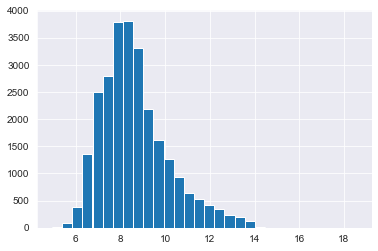

In [224]:
mar['Pace'].hist(bins=30)

In [225]:
fast=mar[(mar['Age']>75)]['Pace'].min()
mar[(mar['Age']>75)&(mar['Pace']==fast)]

,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,5K,...,30K,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,TimeInMinutes
11886,20278,"Taivassalo, Keijo K.",76,M,Thornhill,ON,CAN,NaN,NaN,0:25:25,...,2:31:34,2:58:15,3:24:16,8.219466,-,3:35:21,11887,8510,1,215.35


Wow, that's 8:13 minutes per mile pace!

What if we wanted to look at the average pace for each US State. First let's check the ```State``` column:

In [226]:
mar.State.isna().sum()

2551

Lot's of missing data. 

In [227]:
mar['State'].describe()

count     24047
unique       69
top          MA
freq       4694
Name: State, dtype: object

Hmm... 50 states but 69 unique values here?

In [228]:
mar['State'].unique()

array([nan, 'MI', 'CA', 'OR', 'CO', 'AZ', 'MO', 'CT', 'QC', 'MA', 'NC',
       'IL', 'NY', 'WA', 'MD', 'NH', 'IA', 'VA', 'PA', 'NJ', 'WI', 'SC',
       'TX', 'OH', 'TN', 'MN', 'FL', 'GA', 'AL', 'HI', 'RI', 'ME', 'OK',
       'UT', 'AB', 'IN', 'DC', 'PE', 'ON', 'KS', 'VT', 'BC', 'ID', 'NE',
       'AK', 'NV', 'KY', 'ND', 'NM', 'AR', 'WV', 'LA', 'NS', 'NB', 'DE',
       'MT', 'SD', 'NL', 'WY', 'MS', 'MB', 'PR', 'NT', 'GU', 'AP', 'SK',
       'AE', 'YT', 'AA', 'VI'], dtype=object)

Aha! These are States in Canada or other places like Guam. We could either leave them in or take them out. I'll leave them in and take all rows where the 'State' column is not null. 

In [229]:
states=mar[mar['State'].notnull()]

Now, we want to split this data frame into groups, one for each state, and take the average over those groups. Python has powerful groupby functionality. Here's an example:

In [230]:
states.groupby('State')[['Age','Pace']].mean().round(2).head() #69 groups of state

,Age,Pace
State,,
AA,35.33,8.24
AB,44.33,8.23
AE,38.33,8.82
AK,44.86,7.99
AL,43.37,8.23


That was what we wanted. This data frame has what's called a multi-index, which is beyond the scope of what we need. It can be avoided as follows:

In [231]:
avg=states[['State','Pace','Age']].groupby('State',as_index=False).mean()
avg

,State,Pace,Age
0,AA,8.236641,35.333333
1,AB,8.230036,44.329787
2,AE,8.821883,38.333333
3,AK,7.994835,44.857143
4,AL,8.234390,43.365385
...,...,...,...
64,WA,8.355855,43.856833
65,WI,8.268105,41.818616
66,WV,8.167413,43.434783
67,WY,8.557252,42.190476


What's the fastest/slowest state?

In [232]:
avg.sort_values(by='Pace')

,State,Pace,Age
43,NT,7.195929,41.000000
5,AP,7.698155,41.500000
53,QC,7.915449,45.262664
3,AK,7.994835,44.857143
12,DC,8.042448,35.837349
...,...,...,...
56,SD,8.894102,42.805556
62,VI,9.051527,50.000000
38,NH,9.081380,42.256560
54,RI,9.175113,40.371622


I'll let you think about why it's probably not fair to say the Massachusetts was the slowest state in the 2015 Boston Marathon!

Examples of statistical questions: 

    * How does age influence marathon time?
    * Were runners faster in 2019 than in 2015?
    * Did women improve more than men from 2015 to 2019?

In [233]:
mod=ols(formula = 'Pace ~ Age', data=mar).fit()

In [234]:
mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Pace   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1441.
Date:                Mon, 20 Mar 2023   Prob (F-statistic):          4.19e-307
Time:                        23:35:45   Log-Likelihood:                -48603.
No. Observations:               26598   AIC:                         9.721e+04
Df Residuals:                   26596   BIC:                         9.723e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.3356      0.036    205.847      0.000       7.266       7.405
Age            0.0310      0.001     37.960      0.000       0.029       0.033
==============================================================================
Omnibus:                     4623.934   Durbin-Watson:                   0.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7999.408
Skew:                           1.135   Prob(JB):                         0.00
Kurtosis:                       4.437   Cond. No.                         169.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<AxesSubplot:xlabel='Age', ylabel='Pace'>

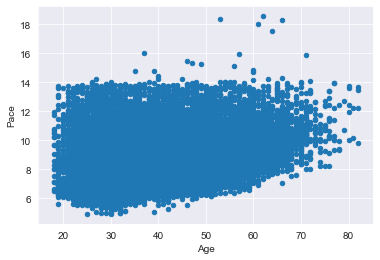

In [235]:
mar.plot.scatter(x='Age',y='Pace')

In [236]:
mar19=pd.read_csv('Boston2019.csv')

In [237]:
mar19.head()

,Rank_Tot,Age,Gender,Country,Result_hr,Result_sec,Rank_Gender,Country_code
0,1,30,M,Kenya,2:07:57,7677,1,KEN
1,2,29,M,Ethiopia,2:07:59,7679,2,ETH
2,3,34,M,Kenya,2:08:07,7687,3,KEN
3,4,32,M,Kenya,2:08:54,7734,4,KEN
4,5,26,M,Kenya,2:08:55,7735,5,KEN


In [238]:
mar19['Pace']=mar19['Result_sec']/(60*26.2)

In [239]:
mar19['Pace'].head() 

0    4.883588
1    4.884860
2    4.889949
3    4.919847
4    4.920483
Name: Pace, dtype: float64

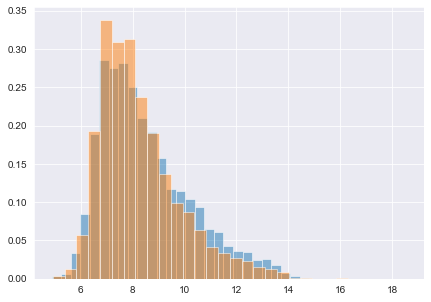

In [240]:
fig, ax = plt.subplots(figsize=(7,5))  # make one subplot (ax) on the figure
ax.hist(mar19[mar19['Gender']=='M']['Pace'],bins=30,alpha=0.5,density=True)
ax.hist(mar[mar['M/F']=='M']['Pace'],bins=30,alpha=0.5,density=True)
plt.show()

In [241]:
from scipy.stats import ttest_ind

In [242]:
s1 = mar19[mar19['Gender']=='M']['Pace']
s2 = mar[mar['M/F']=='M']['Pace']

ttest_ind(s1, s2)

Ttest_indResult(statistic=12.580799794507046, pvalue=3.3423041860099955e-36)

In [243]:
print(np.round(s1.mean(),2),np.round(s2.mean(),2))
print(len(s1),len(s2))

8.51 8.27
14670 14581


One last example of merging data frames: Two datasets of NBA players that contain different but overlapping statistics.

In [244]:
nba_adv=pd.read_csv('NBA2021.csv',encoding='latin')
nba_adv.head()

,Rk,Player,ID,Pos,Age,Tm,G,MP,PER,TS%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,1,Precious Achiuwa,achiupr01,PF,21,MIA,61,737,14.2,0.550,...,13.5,19.5,0.3,1.0,1.3,0.085,-3.6,-0.5,-4.1,-0.4
1,2,Jaylen Adams,adamsja01,PG,24,MIL,7,18,-6.5,0.125,...,0.0,18.6,-0.1,0.0,-0.1,-0.252,-15.1,-4.6,-19.8,-0.1
2,3,Steven Adams,adamsst01,C,27,NOP,58,1605,15.1,0.596,...,17.5,11.7,2.3,1.7,4.0,0.119,-0.4,0.1,-0.3,0.7
3,4,Bam Adebayo,adebaba01,C,23,MIA,64,2143,22.7,0.626,...,15.0,23.7,5.6,3.2,8.8,0.197,2.9,2.0,4.9,3.7
4,5,LaMarcus Aldridge,aldrila01,C,35,TOT,26,674,15.7,0.556,...,7.9,22.2,0.5,0.6,1.1,0.080,-0.2,-0.2,-0.3,0.3


In [245]:
nba_adv.columns

Index(['Rk', 'Player', 'ID', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%',
       '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%',
       'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP'],
      dtype='object')

In [246]:
nba_raw=pd.read_csv('NBA2021Raw.csv',encoding='latin')
nba_raw.head()

,Rk,Player,ID,Pos,Age,Tm,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Precious Achiuwa,achiupr01,PF,21,MIA,61,4,737,124,...,0.509,73,135,208,29,20,28,43,91,304
1,2,Jaylen Adams,adamsja01,PG,24,MIL,7,0,18,1,...,NaN,0,3,3,2,0,0,0,1,2
2,3,Steven Adams,adamsst01,C,27,NOP,58,58,1605,189,...,0.444,213,301,514,111,54,38,78,113,438
3,4,Bam Adebayo,adebaba01,C,23,MIA,64,64,2143,456,...,0.799,142,431,573,346,75,66,169,145,1197
4,5,LaMarcus Aldridge,aldrila01,C,35,TOT,26,23,674,140,...,0.872,19,99,118,49,11,29,27,47,352


In [247]:
nba_raw.columns

Index(['Rk', 'Player', 'ID', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')

In [248]:
print(nba_adv.shape, nba_raw.shape)

(705, 28) (705, 31)


Same number of rows -- one for each player. Let's see what overlap there is among the columns. If we want to merge, we may want to avoid the columns that appear in both (except for the merge keys) since they'll result in duplicate columns. 

In [249]:
set(nba_adv.columns)&set(nba_raw.columns)

{'Age', 'G', 'ID', 'MP', 'Player', 'Pos', 'Rk', 'Tm'}

Let's merge on ```Player``` and ```Tm```. Drop the other common columns from one...

In [250]:
nba_advD=nba_adv.drop(['Age', 'G', 'ID', 'MP', 'Pos', 'Rk',],axis=1)

In [251]:
nba=nba_raw.merge(nba_advD,on=['Player','Tm'])

In [252]:
nba.shape

(705, 51)

In [253]:
nba.columns

Index(['Rk', 'Player', 'ID', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%',
       'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM',
       'BPM', 'VORP'],
      dtype='object')

<AxesSubplot:xlabel='FG%', ylabel='OBPM'>

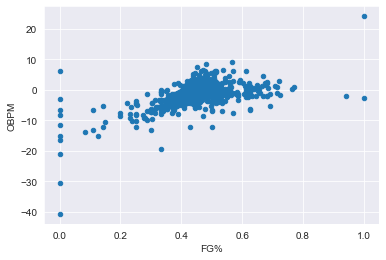

In [254]:
nba.plot.scatter(x='FG%',y='OBPM')

What's up with players whose FG% is 0? Maybe they didn't take many shots.

In [255]:
nba[nba['FG%']==0]['FGA']

49     2
82     1
83     3
127    1
264    4
406    1
507    1
516    1
654    3
679    3
Name: FGA, dtype: int64

Indeed! Maybe some players never took any shots?

In [256]:
nba[nba['FG%'].isna()]

,Rk,Player,ID,Pos,Age,Tm,G,GS,MP,FG,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
126,100,Gary Clark,clarkga01,SF,26,DEN,2,0,4,0,...,0.0,0.037,-4.400,-2.0,-6.5,0.0,NaN,NaN,NaN,NaN
250,195,Ashton Hagans,haganas01,PG,21,MIN,2,0,4,0,...,0.0,0.000,-0.353,-13.7,-7.4,-21.1,0.0,NaN,NaN,NaN


So maybe we drop these players. Small sample size is probably an issue:

<AxesSubplot:>

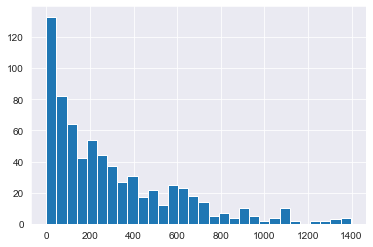

In [257]:
nba['FGA'].hist(bins=30)

<AxesSubplot:xlabel='MP', ylabel='FG%'>

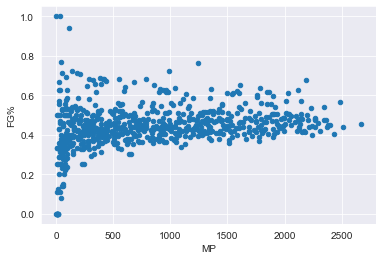

In [258]:
nba.plot.scatter(x='MP',y='FG%')

Best and worst FG% occur among players with very little playing time.

<AxesSubplot:xlabel='MP', ylabel='FG%'>

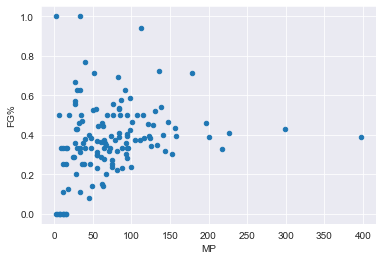

In [259]:
nba[nba['FGA']<50].plot.scatter(x='MP',y='FG%')

<AxesSubplot:xlabel='MP', ylabel='FG%'>

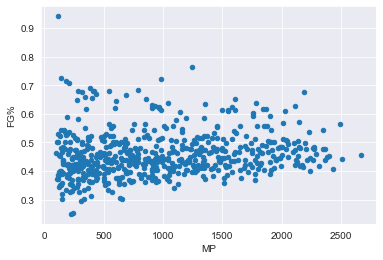

In [260]:
nba[nba['MP']>=100].plot.scatter(x='MP',y='FG%')

Still not perfect but better. Always have to make some decisions.

# ML Overview

The basic problem:


$$
Y=f(X)+\epsilon
$$


$Y$ is the response, $X$ is a set of features, $f$ is the relationship between $X$ and $Y$. 

$\epsilon$ is the random error: independent of $X$ with mean $0$.

Our job: Estimate $Y$ with a model $\hat{f}$:

$$\hat{Y} = \hat{f}(X)$$

## Two broad classes of problems: Regression and Classification

**Regression**: Predict a quantitative response $Y$ using inputs $X_1,\ldots X_p$. Inputs, or features, or predictors, can typically be quantitative or categorical. 

*Example*: predict rent given neighborhood, square footage, number of bathrooms, type of buildiong etc. (Quantitative response: salary, stock price, weight, etc.)

As opposed to a mpre statistical modeling question like, *how can we quantify the effect of age on marathon time?*

**Classification** is trying to predict a class label (to which group does an observation belong) from input variables. 

*Example*: is this an image of a face, or a cat; what customer profile does an individual belong to, is this MRI image pathological or normal, is this player a guard, forward, or center (given statistics). 

## Start with regression. 

We typically have to guard against two problems: *Overfitting* and *Underfitting*.

Let's demonstrate these ideas: first we generate data according to a simple linear relationship:

In [261]:
np.random.seed(1)
df=pd.DataFrame()
df['x'] = np.linspace(0,10,num=7)
df['y'] = df['x'] + np.random.normal(0,2,size=7)

So we know the relationship between $x$ and $y$:
$$
y=x+\epsilon
$$
where $\epsilon \sim N(0,4)$: variance = 4, standard deviation  = 2

In [262]:
df

,x,y
0,0.000000,3.248691
1,1.666667,0.443154
2,3.333333,2.276990
3,5.000000,2.854063
4,6.666667,8.397482
5,8.333333,3.730256
6,10.000000,13.489624


The true slope is 1, the true intercept is 0.

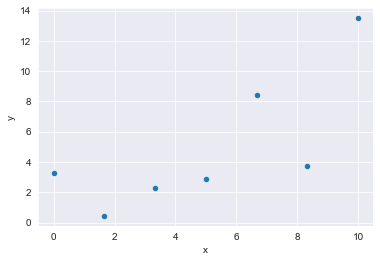

In [263]:
df.plot.scatter(x='x',y='y');

Let's build some models:

In [264]:
mod1=ols(formula='y~x',data=df).fit()
mod2=ols(formula='y~x+np.power(x,2)+np.power(x,3)+np.power(x,4)+np.power(x,5)+np.power(x,6)',data=df).fit()
mod3=df['y'].mean()

Now we have three models. 

* The first is a linear regression model that assumes that $Y$ is a linear function of $X$, and that the error follows a normal distribution which has mean 0 and fixed, constant variance no matter the value of $X$. (Both assumptions here are, in fact, true!) 

* The second model is much more flexible (can model more compex relationships between $x$ and $y$). It assumes that $y$ is a degree 6 polynomial in $x$, and fits parameters so that:
$$
y=\hat{\beta_0}+\hat{\beta}_1x+\hat{\beta}_2x^2+\hat{\beta}_3x^3+\hat{\beta}_4x^4+\hat{\beta}_5x_5+\hat{\beta}_6x^6
$$

* The third model just predicts the average value of the $y$'s... we can think of that as an extremely simple and extremely inflexible model.

In [265]:
df['ymod1']=mod1.predict(df['x'])
df['ymod2']=mod2.predict(df['x'])
df['ymod3']=df['y'].mean()

Let's make predictions for $y$ using the $x$ values and each of the models.

In [266]:
df

,x,y,ymod1,ymod2,ymod3
0,0.000000,3.248691,0.268163,3.248691,4.920037
1,1.666667,0.443154,1.818787,0.443154,4.920037
2,3.333333,2.276990,3.369412,2.276990,4.920037
3,5.000000,2.854063,4.920037,2.854063,4.920037
4,6.666667,8.397482,6.470662,8.397482,4.920037
5,8.333333,3.730256,8.021287,3.730256,4.920037
6,10.000000,13.489624,9.571911,13.489624,4.920037


Which is best?

In [267]:
b0,b1=mod1.params
a0,a1,a2,a3,a4,a5,a6=mod2.params

In [268]:
print(b0,b1) # The intercept and slope of the linear model

0.2681625027610983 0.9303748864337467


In order to plot the polynomial model and have it appear smooth we can use more $x$ values and use the model to predict the corresponding $y$:  

In [269]:
morex=np.linspace(0,10,num=100) 

Plot them all together with some matplotlib code:

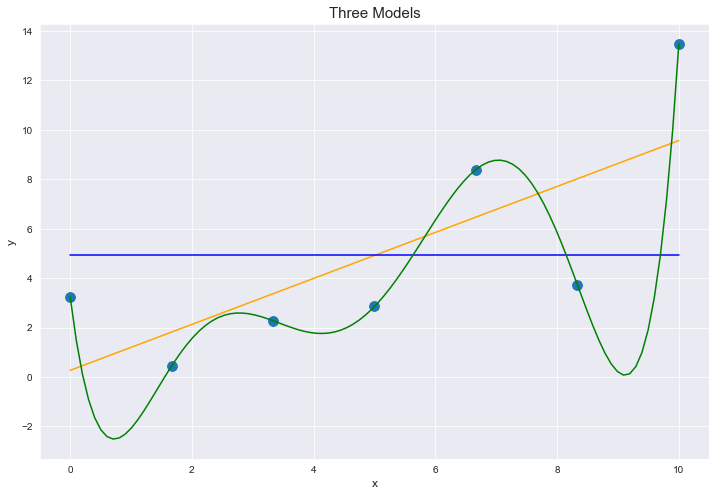

In [270]:
fig, ax = plt.subplots()
plt.scatter(df['x'], df['y'], s=95)
plt.plot(df['x'], df['x']*b1 + b0, c='orange')
plt.plot(df['x'], df['ymod3'], c='blue')
plt.plot(morex, np.power(morex,6)*a6+np.power(morex,5)*a5+np.power(morex,4)*a4+np.power(morex,3)*a3+np.power(morex,2)*a2+morex*a1 + a0, c='green')
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Three Models",fontsize=15)
fig.set_size_inches(12, 8)
plt.show();

The polynomial model which goes through every point exactly. 

However, we know that's because a degree 6 polynomial can go through *any* 7 points. 

If we sample a bunch of new inputs the polynomial model will probably do poorly predicting the corresponding $Y$ values.

In [271]:
np.random.seed(1)
morey=morex+np.random.normal(0,2,size=100)

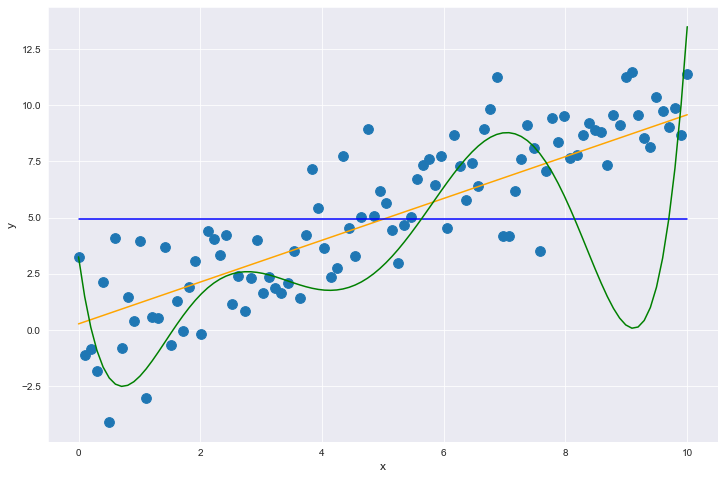

In [272]:
fig, ax = plt.subplots()
plt.scatter(morex, morey, s=95)
plt.plot(df['x'], df['x']*b1 + b0, c='orange')
plt.plot(df['x'], df['ymod3'], c='blue')
plt.plot(morex, np.power(morex,6)*a6+np.power(morex,5)*a5+np.power(morex,4)*a4+np.power(morex,3)*a3+np.power(morex,2)*a2+morex*a1 + a0, c='green')
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
fig.set_size_inches(12, 8)
plt.show()

The linear model is now clearly better!

This polynomial model is an example of **overfitting**: A highly flexible model (like the deg 6 polynomial) will overfit the training data but then generalize poorly to new data that the model hasn't seen before. (Emphasizing the importance of the test set in modeling!)

By contrast, the constant (mean) model is **underfitting**-- it's not flexible enough to reflect the true relationship between $x$ and $y$.

This is also an example of the bias variance tradeoff. 

**Bias**: If $f$ gives the true relationship between inputs and outputs, and $\hat{f}$ is our model of that relationship, then bias is $f-\hat{f}$. Usually our $\hat{f}$ is just an oversimplified approximation to $f$ (eg. relationship is linear), so the model has some bias.

Note: There is also irreducible bias: represented by the error from the $N(0,4)$ term above... independent of $X$.

A more flexible model has low bias (on the training data) whereas a less flexible model has higher bias. 

**Variance**: But, the more flexible model has high variance: If you fit the model on a new training set it would change *a lot*. The less flexible models, by contrast, have lower vairance: they will not change all that much on new training data. 

For example, if we generate 6 new points using the same exact underlying process: 

In [273]:
np.random.seed(2)
df2=pd.DataFrame()
df2['x'] = np.linspace(0,10,num=7)
df2['y'] = df2['x'] + np.random.normal(0,2,size=7)

And refit a degree 6 polynomial:

In [274]:
newmod2=ols(formula='y~x+np.power(x,2)+np.power(x,3)+np.power(x,4)+np.power(x,5)+np.power(x,6)',data=df2).fit()

In [275]:
c0,c1,c2,c3,c4,c5,c6=newmod2.params

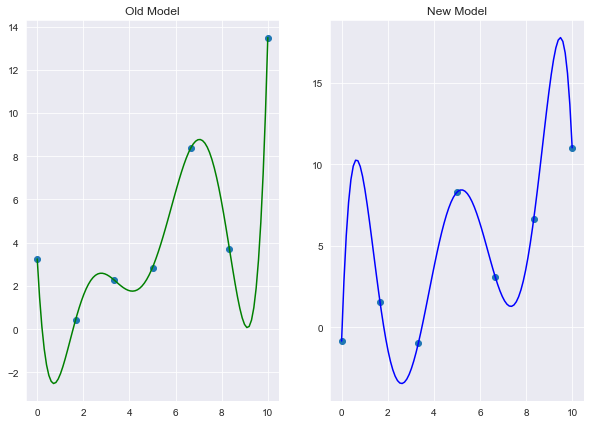

In [276]:
fig, axes = plt.subplots(nrows=1,ncols=2)
axes[0].plot(df['x'], df['y'],'o')
axes[0].plot(morex, np.power(morex,6)*a6+np.power(morex,5)*a5+np.power(morex,4)*a4+np.power(morex,3)*a3+np.power(morex,2)*a2+morex*a1 + a0, c='green')
axes[0].title.set_text('Old Model')
axes[1].plot(df2['x'], df2['y'],'o')
axes[1].plot(morex, np.power(morex,6)*c6+np.power(morex,5)*c5+np.power(morex,4)*c4+np.power(morex,3)*c3+np.power(morex,2)*c2+morex*c1 + c0, c='blue')
axes[1].title.set_text('New Model')
fig.set_size_inches(10, 7)
plt.show()

Much of what we do in ML is trying to fit good models with relatively low bias and relatively low variance that will generalize well to data that was not used in the model building process.

While it may be easy to achieve low bias with an etremely flexible model, the end result is likely be unsatisfactory if it also has high variance and does not generalize well to new data.

One way to help with the problem of overfitting is to have more training data (though this is obviously not always possible). 

In [277]:
bigdf=pd.DataFrame({'x':morex,'y':morey})
#Now fit a degree 6 model to 100 points instead of 7 points:
polymod = ols(formula='y~x+np.power(x,2)+np.power(x,3)+np.power(x,4)+np.power(x,5)+np.power(x,6)',data=bigdf).fit()
bigdf['polymod']=polymod.predict(bigdf['x'])

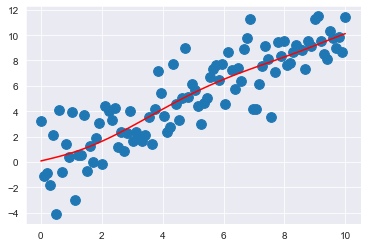

In [278]:
plt.scatter(morex, morey, s=95)
plt.plot(bigdf['x'],bigdf['polymod'],c='red')
plt.show()

Now, even though we're using the flexible degree 6 model, the fit is very close to the linear model. The linear model is still simpler (and better -- if $x^2,\ldots x^6$ have no bearing on $y$ then it's better to not include them in the model), but now the more flexible model will generalize better to new data.

Strategies to prevent overfitting: 
1. Use a less complex model (fewer parameters) 
2. Use more training data 
3. Evaluate model performance on test data the model has not seen.

### What is the difference between machine learning and statistical modeling?

Often it's in the assumptions of the model: like $\epsilon \sim N(0,\sigma^2)$, resulting statistical properties of model parameters (think: t-tests, confidence intervals, etc.), and...

Also interpretability: ML is often/usually more concerned with prediction than interpretation (black boxes might be OK). Statistical models often lend themselves more readily to interpretations. 

Let's look at a data set of fuel efficiency for older model cars.

In [279]:
cars=pd.read_csv('morecars.csv')
cars.head()

,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


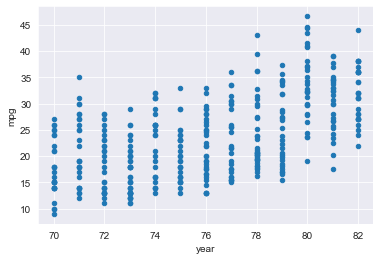

In [280]:
cars.plot.scatter(x='year',y='mpg');

We might be interested in predicting $mpg$ from other features (a regression probelm) or deciding from those features whether or not a car is fuel efficient (defined as gets better than median $mpg$) -- a (two-class) classification problem.

In [281]:
cars['Eff']=np.where(cars['mpg']>=cars['mpg'].median(),1,0)
cars.head(20)

,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,Eff
0,0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0
1,1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0
2,2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0
3,3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0
4,4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0
5,5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500,0
6,6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala,0
7,7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii,0
8,8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina,0
9,9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl,0


Let's check that this worked the way we expect: we should see higher average mpg in cars where Eff = 1 versus Eff = 0. 

We can groupby 'Eff' and compute means...

In [282]:
cars.groupby('Eff').mean()['mpg']

Eff
0    16.94264
1    29.99050
Name: mpg, dtype: float64

Sometimes we want to apply different functions to different columns. For example, compute ```mean```, ```count``` and ```std``` for ```mpg```; but ```mean```, ```count```, and ```median``` for ```horsepower```. 

Use the agg function for this:

In [283]:
cars.groupby('Eff').agg({'mpg':['mean','count','std'],'horsepower':['mean','count','median']})

TypeError: Could not convert 130165150150140198220215225190170160150225959785902152002101931001051008810016517515315018017017511072100889086165175150153150208155160190971501301401501127687861751501451371501981501581502152251751051001008815016717018010088729490851071452309111215012218095?100100100110105140150150140150951057272170145150148110105110951101101291009790981401501201521001059010078110951021508810812018014513015014511014513011010510098180170190149971101101101401391059585100901058511012014516513914095103125115133115858890110130129138135155142125150901108885112 to numeric

#### Whoops!

In [ ]:
cars.dtypes

In [ ]:
cars['horsepower'].head()

The *horsepower* column looks like numbers but isn't.

In [ ]:
cars.loc[0,'horsepower']*2

In [ ]:
cars['horsepower'].describe()

In [ ]:
cars['horsepower']=pd.to_numeric(cars['horsepower'],errors='coerce')

In [ ]:
cars.groupby('Eff').agg({'mpg':['mean','count','std'],'horsepower':['mean','count','median']}).round(2)

Note, the count value tells us that some cars are missing ```horsepower``` values.

In [ ]:
cars[['horsepower','mpg']].isna().sum()

Let's look at the distribution of 'mpg'

In [ ]:
cars['mpg'].hist(bins=20)

And broken down by the two ```Eff``` labels.

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))  # make one subplot (ax) on the figure
ax.hist(cars[cars['Eff']==0]['mpg'],bins=10,alpha=0.5,density=True)
ax.hist(cars[cars['Eff']==1]['mpg'],bins=10,alpha=0.5,density=True)
plt.show()

As above (and last module?), we can use ```statsmodels``` to build regression models with nice ```R``` style summary output:

In [ ]:
yr_mod=ols(formula='mpg~year+cylinders',data=cars).fit()
yr_mod.summary()

Our primary tool for model building in Machine Learning will be a python package called ```sklearn```. 

We can build the same regression model in ```sklearn``` :

In [ ]:
from sklearn import linear_model

In ```sklearn``` we always separate the features ($X$) and the response ($y$)

In [ ]:
Xc=cars[['year','cylinders']]
yc=cars['mpg']

In [ ]:
car_reg = linear_model.LinearRegression().fit(Xc,yc)

We have to hunt for the info:

In [ ]:
car_reg.intercept_

In [ ]:
car_reg.coef_

To get R^2:

In [ ]:
car_reg.score(Xc, yc).round(3)

Not bad?

And we don't get $t$-statistics, $p$-values, confidence intervals, diagnostics, etc. Shows the difference in philosophy maybe? 

The documentation in ```sklearn``` is very useful for navigating the info you want: [Linear Regression Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

We broke cardinal rule #1 by not plotting the data

In [ ]:
cars.plot.scatter(x='horsepower',y='mpg');

Hmmm... maybe nonlinear?

```Seaborn``` is a nice package for plotting. Here it gives a nice quick visual of the linear model. 

In [ ]:
sns.lmplot(x='horsepower',y='mpg',data=cars)

Or maybe different trends for higher and lower efficiency vehicles?

In [ ]:
sns.lmplot(x='horsepower',y='mpg',hue='Eff',data=cars)

In [ ]:
hp_mod=ols(formula='mpg~horsepower',data=cars).fit()
hp_mod.summary()

We can build two separate models for each ```Eff``` category as pictured above using an indicator variable:

In [ ]:
hpe_mod=ols(formula='mpg~horsepower+Eff',data=cars).fit()
hpe_mod.summary()

That helps. Maybe can do even better by adding in year? 

In [ ]:
hpey_mod=ols(formula='mpg~horsepower+Eff+year',data=cars).fit()
hpey_mod.summary()

Better still. Newer cars seem more efficient. All variables are statistically significant. One more try...

In [ ]:
hpeq_mod=ols(formula='mpg~horsepower+np.power(horsepower,2)+Eff+year',data=cars).fit()
hpeq_mod.summary()

Another example... Goal: Predict bodyfat from clinical measurements.

In [ ]:
bfat=pd.read_csv('Bodyfat.csv').drop('Density',axis=1)
bfat.head()

In [ ]:
bfat.shape

In [ ]:
bfat[['bodyfat','Age','Weight','Hip','Ankle','Wrist']].corr().round(2)

Let's take a quick look at the pairwise correlations between variables. But be cafreful... this can take a while on large data. Here we're OK.

In [ ]:
sns.pairplot(bfat[['bodyfat','Age','Weight','Hip','Ankle','Wrist']])

The hip measurement seems correlated with bodyfat.

In [ ]:
hip_mod=ols(formula='bodyfat~Hip',data=bfat).fit()
hip_mod.summary()

Now maybe add in age? Seems correlated with bodyfat (weaker) but also not too correlated with hip.

In [ ]:
ha_mod=ols(formula='bodyfat~Hip+Age',data=bfat).fit()
ha_mod.summary()

In [ ]:
a_mod=ols(formula='bodyfat~Age',data=bfat).fit()
a_mod.summary()

In [ ]:
bfat[['Hip','Age']].corr()

Or maybe try a kitchen sink model?

In [ ]:
preds="+".join(bfat.columns[i] for i in range(1,len(bfat.columns))) 
preds

In [ ]:
bfat_mod=ols(formula='bodyfat~' + preds,data=bfat).fit()

In [ ]:
bfat_mod.summary()

We've definitely achieved a higher $R^2$ but perhaps at the expense of a model that makes sense on the level of individual predictors. See, for instance, negative coefficients oi variables like Weight.

Multicolinearity quickly becomes an issue. 

In [ ]:
bfat_mod2=ols(formula='bodyfat~Age+Weight+Neck+Chest+Hip+Wrist' ,data=bfat).fit()
bfat_mod2.summary()

Recall that the OLS model minimizes:
$$
\sum (y-\hat{y})^2
$$
where
$$
\hat{y} = \beta_0+\beta_1x_1+\cdots \beta_px_p
$$
(sum over all observations $(x_{i1},x_{i2},\ldots,x_{ip},y_i))$

This is the **loss function**: we think of this as a function of the parameters (the $\beta$'s) and find the minimum. This is a calculus problem and is typically solved using (a flavor of) gradient descent. 

Here we're minimizing the vertical distance between the observed data and the model prediction. 

In general, linear regression is a relatively low-variance method. The linear model isn't particularly sensitive to changes in the training data as long as the number of observations is large relative to the number of predictors $n>p$ and the predictors are themselves not too highly correlated. 

As we've seen, though, when we have many highly correlated predictors the OLS model can also have high variance. One way to reduce the variance is to introduce a penalty into the loss function so that the model prefers smaller values of the coeficients. This is known as shrinkage or penalized regression. The two most widely used versions are **ridge regression** and **lasso regression**.  

**Ridge**: Minimize
$$
\sum\left(y-\hat{y}\right)^2+\lambda\left(\sum_{i=1}^p\beta_i^2\right)
$$

$$
=RSS+\lambda\|\bf{\beta}\|_2^2
$$

Here, $\lambda$ is a parameter that controls the size of the penalty. The larger $\lambda$ is, the more we shrink the $\beta$'s to compensate. Smaller $\lambda$ means we pay more attention to $RSS$, and when $\lambda=0$ we're back at the OLS model.  

Note: This is an example of the so-called bias-variance tradeoff. As we've seen above, Often models with low bias have high variance. Here, we are intoducing some bias (the penalty means we're no longer taking the best least-squares fit) in exchange for lower variance which can lead to better performance on a test set (or new data).  

In fact, for very large $\lambda$ we would be very close to anull model where all $\beta_i$ are close to 0 except $\beta_0$. This model essentially predicts the average value of the observed $y$'s regardless of the input variables. Indeed this model has very high bias and very low variance.   

You probably though a fair bit about ridge and lasso last module. Lasso regression is very much like the ridge model above only the shrinkage penalty uses the absolute value (rather than the sqaure) of the model parameters. (The 1-norm rather than the 2-norm.)

### Cross Validation

We have several issues to deal with when building a model. First, we need to train the model on part of our data and test it on new data that wasn't used in training. 

At the same time, the more data we use to build the model, the better (usually) so it hurts to give up too much of our data to the test set. 

Furthermore, we need a way to choose the value of parameter(s) in the model. In the ridge (or lasso) example above we have the parameter $\lambda$. 

Typical data science workflow: Split the data into a training set and a test set. We decide on how big the test set is based on how much data we have and how much we think we need to train well: 20%, 30%, 40%?

``` scikit-learn ``` has functionality to make this easy.

Next, split the *training set* into $k$ equal sized folds. Usually $k=5$ or $k=10$.

Then: Put aside fold 1. For a fixed value of $\lambda$, train the model using the data in folds 2 through $k$. Evaluate your model's performance using fold 1 as a test set to get a test-set error estimate.

For regression, we might use MSE (mean squared error) and get $MSE_1$ for the error on the test-fold 1.

Now, repeat using each fold as the test set and the remaining folds for training. That is, hold out fold-2 for testing and train on $1,3,4,5,\ldots 10$. We get error estimate $MSE_2$

Finally, consider:
$$
CV_{\lambda} = \frac{1}{k}\sum_{i=1}^k MSE_i
$$

<img src="FFCV_ISLR.png">

##### (from ISLR by James, Witten, Hastie, Tibshirani)

Now, we can repeat the above training/testing procedure over a set of possible values for $\lambda$. The one with the lowest error rate (smallest $CV_{\lambda}$) indicates the optimal choice for the $\lambda$ parameter.

Note: We can now re-train the model for this $\lambda$ but we will still need a clean test set (unseen by the model) to estimate the performance.

### We can use Cross Validation to choose the model, or, to tune the parameters in a given model (The $\lambda$ in Ridge regression, for instance).  

First we do an example of choosing the model. Note this is similar to the thought process used above but is more mechanical...

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
cars.head()

Let's build a model that predicts ```mpg``` using ```horsepower``` as a predictor. We will consider the possibility, however, that horsepower influences ```mpg``` non-linearly through higher order terms in the model.

Let's drop the na values though we might reasonably impute missing horsepower here -- maybe average hp for similar weight/cyl cars?

In [ ]:
cars=cars.dropna()

In [ ]:
cars.shape

In [ ]:
X=cars[['horsepower']].copy()
y=cars[['mpg']]

In [ ]:
X['hp2']=X['horsepower']**2
X['hp3']=X['horsepower']**3
X['hp4']=X['horsepower']**4

We'll try fitting polynomial models of degree 1,2,3 and 4, and choose the one that's best  using cross-validation. 

In [ ]:
reg = linear_model.LinearRegression()
cv1_results = cross_validate(reg, X[['horsepower']], y, cv=5,scoring=('r2', 'neg_mean_squared_error'))
cv2_results = cross_validate(reg, X[['horsepower','hp2']], y, cv=5,scoring=('r2', 'neg_mean_squared_error'))
cv3_results = cross_validate(reg, X[['horsepower','hp2','hp3']], y, cv=5,scoring=('r2', 'neg_mean_squared_error'))
cv4_results = cross_validate(reg, X[['horsepower','hp2','hp3','hp4']], y, cv=5,scoring=('r2', 'neg_mean_squared_error'))

In [ ]:
cv3_results

Let's look at the test-set error on each of the five folds for the quadratic model using $R^2$:

In [ ]:
cv2_results['test_r2']

... and using neg mean squared error:

In [ ]:
cv2_results['test_neg_mean_squared_error']

So this shows the (negative) mean squared error on each of the five folds (being used as the test set).

In [ ]:
-cv2_results['test_neg_mean_squared_error'].round(3)

In [ ]:
-cv2_results['test_neg_mean_squared_error'].mean().round(3)

Let's look at the average error (over the five folds) for each of the four models.

In [ ]:
print(-cv1_results['test_neg_mean_squared_error'].mean().round(3),-cv2_results['test_neg_mean_squared_error'].mean().round(3).round(3),-cv3_results['test_neg_mean_squared_error'].mean().round(3),-cv4_results['test_neg_mean_squared_error'].mean().round(3))

Cross validaiton chooses the quadratic model. It has considerably lower avg MSE than the linear model, and higher order models do not improve.

In [ ]:
cvs=[-cv1_results['test_neg_mean_squared_error'].mean(),-cv2_results['test_neg_mean_squared_error'].mean(),-cv3_results['test_neg_mean_squared_error'].mean(),-cv4_results['test_neg_mean_squared_error'].mean()]
degs=[1,2,3,4]
plt.plot(degs,cvs)
plt.xlabel('degree')
plt.ylabel('MSE')
plt.show()

Note: we would have gotten the same result if we had used $R^2$ as our scoring metric: 

In [ ]:
print(cv1_results['test_r2'].mean().round(3),cv2_results['test_r2'].mean().round(3).round(3),cv3_results['test_r2'].mean().round(3),cv4_results['test_r2'].mean().round(3))

Finally, we can refit the model on the combined training data (all folds).

In [ ]:
hpreg = linear_model.LinearRegression().fit(X[['horsepower','hp2']],y)

In [ ]:
hpreg.score(X[['horsepower','hp2']], y)

Note: The $R^2$ here is considerably higher than it was on the test fold. We would check our model on the hold out test set now to see how it really does.

Here are the intercept and the two coefficients (of ```hp``` and squared ```hp```) in the model. 

In [ ]:
print(hpreg.intercept_,hpreg.coef_)

By the way, we get the same model using ```statmodels```...

In [ ]:
hpq_mod=ols(formula='mpg~horsepower+np.power(horsepower,2)',data=cars).fit()
hpq_mod.summary()

**Note**: By using the test folds to choose the model degree, however, we've used that data to tune the model. Thus, we still need a test set to see how it does on unseen data.

In [ ]:
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.model_selection import train_test_split

### Choosing a parameter

For ridge regression we need to use cross validation to choose the optimal $\lambda$. Typically, we try a whole array of values from very large to very small.

Let's take 100 evenly spaced values between -3 and 5... 

In [ ]:
np.linspace(5,-3,100)

...and then use them as exponents of 10 for the $\lambda$ values. So, $10^5$ is very big (close to the null model where all $\beta$s are 0) and $10^{-3}$ is very small (close to OLS).

In [ ]:
lambdas = 10**np.linspace(5,-3,100)
lambdas

Now split the data into training and test sets.

Let's use ridge regression on the ```bfat``` dataset.

In [ ]:
bfat.head()

```scikit-learn``` or ```sklearn``` requires the inputs and response in separate data frames (or np arrays). Also, we can't have ```nan``` values or non-numerical values, so we'll have to numerically code any categorical variables. (None in bfat, though.)

Let's drop the response variable (bodyfat) and keep all the remaining variables as predictors. We suspect, however, a good deal of multicolinearity in the remaining predictors. Ridge seems like a good option.

In [ ]:
Xf=bfat.drop('bodyfat',axis=1)
yf=bfat['bodyfat']

In [ ]:
Xf.head()

```sklearn```'s ```train_test_split``` function is extremely convenient to split the data.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(Xf, yf, test_size=0.25, random_state=5)

In [ ]:
print(Xf_train.shape,Xf_test.shape, yf_train.shape,yf_test.shape)

sklearn uses $\alpha$ for what we called $\lambda$. Remember, $\lambda=0$ is OLS.

In [ ]:
from sklearn.linear_model import Ridge

Recall that because of the penalty term we have to normalize the data. (Not true if we're just doing plain vanilla OLS.) 

In [ ]:
ols_bfat = Ridge(alpha=0,normalize=True)
ols_bfat.fit(Xf_train, yf_train)

```sklearn``` is warning us that the built-in normalization in the Ridge call is going away soon. We will need to do the normalization as we prep the data. OK -- we'll deal with thois soon but keep goping for now. 

Let's use Mean Squared Error to compare models, and let's see what teh baseline OLS model looks like before we try the Ridge model.

In [ ]:
from sklearn.metrics import mean_squared_error

We can use MSE on the test set to measure the OLS model built on the training data.

In [ ]:
mean_squared_error(ols_bfat.predict(Xf_test),yf_test).round(2)

Now, we use cross validation (I'm using 5 fold here) to choose the optimal value of $\lambda$. ```sklearn``` has a convenient built-in cross validation function for Ridge regression. 

In [ ]:
from sklearn.linear_model import RidgeCV

In [ ]:
ridgecv = RidgeCV(alphas = lambdas, scoring = 'neg_mean_squared_error', normalize = True,cv=5)
ridgecv.fit(Xf_train, yf_train)

Again, lots of warnings about the internal normalization. 

In [ ]:
ridgecv.alpha_

This is the optimal $\lambda$ using 5-fold cross validation on the training set.

Next, we can train the Ridge model on the full training data using this optimal $\lambda$ from CV:

In [ ]:
ridgemod = Ridge(alpha = ridgecv.alpha_, normalize = True)

In [ ]:
ridgemod.fit(Xf_train, yf_train)

And use test MSE to see how it compares to the OLS model.

In [ ]:
mean_squared_error(ridgemod.predict(Xf_test),yf_test).round(2)

The OLS model error was higher: 16.53

We can also compare the $R^2$ of each model using ```score```:

In [ ]:
ridgemod.score(Xf_test,yf_test).round(3)

In [ ]:
ols_bfat.score(Xf_test,yf_test).round(3)

The ridge penalty improved the model performance (slightly) on the test set. 

Introducing some bias into the model reduces variance and generalizes better on new data.

In [ ]:
ridgemod.coef_

Still have some negatve coeficients in there -- maybe not the best for interpretation but a reasonable predictive model.

In [ ]:
Xf.columns

There are other versions of cross validation including leave-one-out (LOOCV) which is default on Ridge in ```sklearn``` (we changed it in our function call) but 5 or 10-fold is usually best. (Since LOOCV uses almost the same training set for each model they're highly correlated and subject to higher variance than the less-correlated $k$-fold models.)

Let's do a classification example using cross valdation.

We'll generate some data using some internal ```sklearn``` functions

In [ ]:
from sklearn import datasets
np.random.seed(1)
mX,my = datasets.make_moons(n_samples=1000)
jig=np.random.normal(0,.25,size=[1000,2])

mdf=pd.DataFrame(mX+jig,columns=['feat1','feat2'])
mdf['Class']=my
mdf.head()

In [ ]:
sns.scatterplot(x='feat1',y='feat2',hue='Class',style='Class',data=mdf)

In classification problems we are trying to predict which class an observation belongs to using the features (here, $x$ and $y$ coordinates of the point).

It's pretty clear that there are two distinct classes. 

It's also pretty clear that there is a *nonlinear decision boundary*.

Let's try implementing logistic regression. We're probably not wildly optimistic about the result since we know that logistic regression fits a linear decision boundary.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X=mdf[['feat1','feat2']]
y=mdf['Class']

We should split into train and test sets but we'll cheat for now and just use the whole dataset.

In [ ]:
clf = LogisticRegression(random_state=0)

In [ ]:
LRclf = clf.fit(X[['feat1','feat2']], y)

After fitting the model (linear in the log odds) we can look at the coeficients:

In [ ]:
LRclf.coef_

and the intercept:

In [ ]:
LRclf.intercept_

And use the fact that the log-odds is 0 when the probability of class 1 is equal to 0.5 to plot the decision boundary:

In [ ]:
b=LRclf.intercept_
b1,b2=LRclf.coef_[0]

f, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(x="feat1", y="feat2",
                hue="Class", style="Class",
                data=mdf, ax=ax)
x_vals = np.array(ax.get_xlim())
y_vals = -b/b2 - (b1/b2) * x_vals
# b+b1x+b2y = log(odds). When prob(class = 1) is 0.5, we have log(odds)=0. 
#Now solve for y in terms of x to get the decision boundary which is the linear equation above. 
plt.plot(x_vals, y_vals, color='black', linestyle='dashed',
     linewidth=3)
plt.show()

In [ ]:
x_vals

That seems like a pretty good try if we're stuck with a linear boundary.

To get a nonlinear boundary we could try other classification algorithms, or, we could try adding polynomial powers of the features to fit the log-odds better and get more flexible decision boundaries.

This is a little less elegant in sklearn than in statmodels, but we can simply add the higher powers of $x$ and $y$ to the data frame manually.

In [ ]:
X['f12']=X['feat1']**2 #feature one squared.
X['f22']=X['feat2']**2 #feature two squared etc.
X['f13']=X['feat1']**3
X['f23']=X['feat2']**3
X['f14']=X['feat1']**4
X['f24']=X['feat2']**4
X['f15']=X['feat1']**5
X['f25']=X['feat2']**5

We still have the Logistic Regression model defined. We just want to fit various (more flexible) versions of the model and see which one is best using cross validation. 

First split the data:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)

Above we defined: ```clf = LogisticRegression(random_state=0)```

Now, just like we did above for regression, we'll fit various models (including regular logistic regression) and test them on the held-out fold. 

How should we evaluate a classifier? We'll use the accuracy of the classifier on the test-fold (much more on this later). We'll fit all models up through a full degree 5 model and stick with 5 fold CV here:

In [ ]:
lcv1_results = cross_validate(clf, X_train[['feat1','feat2']], y_train, cv=5,scoring='accuracy')
lcv2_results = cross_validate(clf, X_train[['feat1','feat2','f12','f22']], y_train, cv=5,scoring='accuracy')
lcv3_results = cross_validate(clf, X_train[['feat1','feat2','f12','f22','f13','f23']], y_train, cv=5,scoring='accuracy')
lcv4_results = cross_validate(clf, X_train[['feat1','feat2','f12','f22','f13','f23','f14','f24']], y_train, cv=5,scoring='accuracy')
lcv5_results = cross_validate(clf, X_train[['feat1','feat2','f12','f22','f13','f23','f14','f24','f15','f25']], y_train, cv=5,scoring='accuracy')

Let's check out the results:

In [ ]:
lcv1_results['test_score'].round(2)

These are the accuracies on each of the five folds used as a test set for the vanilla logistic regression model. For the degree 1,2,3,4,5 models:

In [ ]:
lcv2_results['test_score'].round(2)

In [ ]:
lcv3_results['test_score'].round(2)

In [ ]:
lcv4_results['test_score'].round(2)

In [ ]:
lcv5_results['test_score'].round(2)

We average over the folds and see which one looks best:

In [ ]:
print(lcv1_results['test_score'].mean().round(2),lcv2_results['test_score'].mean().round(2),lcv3_results['test_score'].mean().round(2),lcv4_results['test_score'].mean().round(2),lcv5_results['test_score'].mean().round(2))

Significant improvement at the degree 3 model, and then very little improvement at degree 4 or 5.

Now, refit on the full training set! Include plain log reg as a comparison:

In [ ]:
deg3mod=LogisticRegression(random_state=0).fit(X_train[['feat1','feat2','f12','f22','f13','f23']],y_train)

In [ ]:
reglrmod=LogisticRegression(random_state=0).fit(X_train[['feat1','feat2']],y_train)

In [ ]:
reglrmod.coef_

In [ ]:
deg3mod.coef_

We'll compare the accuracy of the two models. First, let's look at the accuracy of the regular logistic regression model:

In [ ]:
lrcm=pd.crosstab(LRclf.predict(X_test[['feat1','feat2']]),y_test)
lrcm

In [ ]:
pd.crosstab(deg3mod.predict(X_test[['feat1','feat2','f12','f22','f13','f23']]),y_test)

We can compute the accuracy by hand or have ```python``` do it for us:

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
#accuracy
accuracy_score(deg3mod.predict(X_test[['feat1','feat2','f12','f22','f13','f23']]),y_test)

In [ ]:
accuracy_score(LRclf.predict(X_test[['feat1','feat2']]),y_test)

We can do a little fancy graphics to plot the decision boundary. Details not particularly important. Create a grid of points and then color them according to how they are classified.

In [ ]:
xx, yy = np.meshgrid(np.linspace(-2, 3, 500), np.linspace(-1.5, 2, 500))
x2=xx**2
y2=yy**2
x3=xx**3
y3=yy**3
X_grid = np.c_[xx.ravel(), yy.ravel(),x2.ravel(),y2.ravel(),x3.ravel(),y3.ravel()]

In [ ]:
zz_lr3 = deg3mod.predict_proba(X_grid)[:,1].reshape(xx.shape)
f, ax = plt.subplots(figsize=(10, 6.6))
sns.scatterplot(x='feat1',y='feat2',hue='Class',style='Class',data=mdf)
plt.contourf(xx, yy, zz_lr3 > 0.5, alpha=0.2)
plt.show()

## Sandbox

###### Breast cancer data (classification)

In [ ]:
from sklearn import datasets
bcd = datasets.load_breast_cancer()
df = pd.DataFrame(bcd['data'], columns=bcd['feature_names'])
df['target'] = bcd['target']
df.head()

In [ ]:
df.shape

Use available features to predict ```target```. Use cross validation to find a good logistic regression model.

##### Boston Housing (regresison, ridge)

In [ ]:
bos=pd.read_csv('Boston.csv')
bos.head()

In [ ]:
bos.shape

Predict ```MEDV``` from available features. Use Ridge and optimize $\lambda$ using cross validation.

###### College basketball data (python, pandas, regression, anything else you want to do!)

In [ ]:
cbb=pd.read_csv('cbb20_wUC.csv')
del cbb['Unnamed: 0']

In [ ]:
#includes only D1 games in the 2019-2020 season
cbb.head()

Use ridge regression to predict efficiency (points scored - points allowed) where the predictors are the teams. Use cross validation to optimize lambda and then use the coeficients to rank the teams from best to worst.